## Modeling

+ Try different methods for creating text embeddings (Word2Vec, TF-IDF, BERT, etc.)

+ Train catboost classifier on all of them

+ Compare the model with text and numeric features againts the numeric features

+ Calculate the metrics, get the results, and their interpretation

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())   # makes 'vectorizer' importable from modeling/

import json, warnings, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score,
)

from vectorizer import preprocess_tokenize, vectorize

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [2]:
df_raw = pd.read_parquet('../data/data_sample/news_prices_full_processed_with_target_v2.parquet')
print(f'Raw dataset: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}):')
print(list(df_raw.columns))

Raw dataset: (84658, 156)
Columns (156):
['date', 'prev_date', 'future_date', 'title', 'description', 'maintext', 'ticker', 'prev_day_price', 'curr_day_price', 'next_day_price', 'named_entities', 'mentioned_companies', 'related_companies', 'sentiment_negative', 'sentiment_neutral', 'sentiment_positive', 'emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness', 'emotion_disgust', 'emotion_surprise', 'emotion_neutral', 'date_day_of_week', 'prev_day_of_week', 'future_day_of_week', 'language', 'curr_prev_per_change', 'next_curr_per_change', 'curr_prev_pos_change', 'next_curr_pos_change', 'title_word_count', 'description_word_count', 'maintext_word_count', 'title + description + maintext', 'title + description', 'S&P500', 'sector', 'industry', 'marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'long_business_summary', 'weight', 'curr_open', 'curr_high', 'curr_low', 'curr_volume', 'curr_day_range', 'curr_day_gap', 'curr_upper_wick', 'curr_lower_wick', 'close_lag2', 'vol

## 2. Outlier Removal & Sampling

In [3]:
TARGET   = 'next_curr_per_change'
TEXT_COL = 'maintext'  # matches what the user will supply to the agent

print('Target distribution (raw):')
print(df_raw[TARGET].describe(percentiles=[.01, .05, .1, .9, .95, .99]))

q01 = df_raw[TARGET].quantile(0.02)
q99 = df_raw[TARGET].quantile(0.99)
print(f'\nClipping to [{q01:.4f}, {q99:.4f}]')

df = (
    df_raw
    .dropna(subset=[TARGET, 'maintext'])
    .query(f'{q01} <= {TARGET} <= {q99}')
    .reset_index(drop=True)
)
print(f'After outlier removal: {df.shape}')

Target distribution (raw):
count    84658.000000
mean         0.000348
std          0.027513
min         -0.951267
1%          -0.060640
5%          -0.031918
10%         -0.022697
50%          0.000661
90%          0.022022
95%          0.033405
99%          0.066453
max          0.197623
Name: next_curr_per_change, dtype: float64

Clipping to [-0.0468, 0.0665]
After outlier removal: (82133, 156)


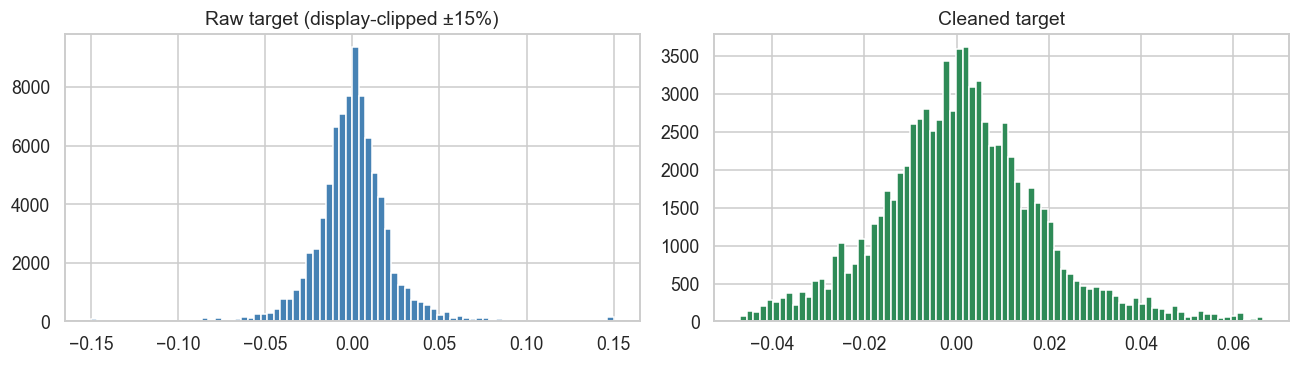

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
df_raw[TARGET].clip(-0.15, 0.15).hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Raw target (display-clipped ±15%)')
df[TARGET].hist(bins=80, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Cleaned target')
plt.tight_layout()
plt.show()

In [5]:
# SAMPLE_FRAC = 0.1
SAMPLE_FRAC = 1 # WE GO THE FULL MODE WE ARE NOT AFRAID OF ANYTHING EXCEPT FOR Jeepers Creepers

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f'Sampled to {SAMPLE_FRAC*100:.0f}%: {df.shape}')
else:
    print(f'Using full dataset: {df.shape}')

Using full dataset: (82133, 156)


## 3. Leakage Prevention

The following columns are **removed before any feature is built**:
- `next_day_price` — this is the numerator of the target; using it is pure leakage  
- `next_curr_pos_change` — binary version of the target  
- `future_date` — a future date that shouldn't be a model input

All lag features in the dataset look *backward* from `date`, so they are safe.  
Current-day OHLCV features assume an **end-of-day prediction window** (article read after market close).

In [6]:
LEAKY_COLS = ['next_day_price', 'next_curr_pos_change', 'future_date']
dropped = [c for c in LEAKY_COLS if c in df.columns]
df = df.drop(columns=dropped)

# Sort chronologically — required for the time-based train/val/test split below
df = df.sort_values('date').reset_index(drop=True)

print(f'Dropped leaky columns: {dropped}')
print(f'Shape after leakage removal: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

Dropped leaky columns: ['next_day_price', 'next_curr_pos_change', 'future_date']
Shape after leakage removal: (82133, 153)
Date range: 2017-01-04 → 2023-12-27


In [7]:
print(list(df.columns))

['date', 'prev_date', 'title', 'description', 'maintext', 'ticker', 'prev_day_price', 'curr_day_price', 'named_entities', 'mentioned_companies', 'related_companies', 'sentiment_negative', 'sentiment_neutral', 'sentiment_positive', 'emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness', 'emotion_disgust', 'emotion_surprise', 'emotion_neutral', 'date_day_of_week', 'prev_day_of_week', 'future_day_of_week', 'language', 'curr_prev_per_change', 'next_curr_per_change', 'curr_prev_pos_change', 'title_word_count', 'description_word_count', 'maintext_word_count', 'title + description + maintext', 'title + description', 'S&P500', 'sector', 'industry', 'marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'long_business_summary', 'weight', 'curr_open', 'curr_high', 'curr_low', 'curr_volume', 'curr_day_range', 'curr_day_gap', 'curr_upper_wick', 'curr_lower_wick', 'close_lag2', 'volume_lag2', 'sp500_lag2', 'close_lag3', 'volume_lag3', 'sp500_lag3', 'close_lag4', 'volume_lag4', '

## 4. Feature Categories

Every feature group is registered in `FEATURE_CATEGORIES`.  
Add the group key to `EXCLUDE_CATEGORIES` to drop the whole group from the model — useful for ablation studies.

| Key | Contents |
|---|---|
| `sentiment` | Pre-computed negative / neutral / positive scores |
| `emotion` | anger, fear, joy, sadness, disgust, surprise, neutral |
| `text_stats` | Word counts for title, description, maintext |
| `price_momentum` | Current-day return (`curr_prev_per_change`) and direction |
| `curr_ohlcv` | Current-day volume, intraday range, gap, wicks |
| `lag_prices` | Raw close prices at lag 2–28 calendar days |
| `lag_volumes` | Volume at lag 2–28 |
| `sp500_current` | S&P 500 level on the article date |
| `lag_sp500` | S&P 500 at lag 2–28 |
| `lag_returns` | Stock return from lagN to current |
| `lag_directions` | Direction (up/down) of those returns |
| `sp500_returns` | S&P 500 return from lagN to current |
| `sp500_directions` | Direction of S&P 500 returns |
| `volume_changes` | Volume change vs each lag + rolling averages |
| `alpha` | Stock return minus S&P 500 return per lag |
| `momentum` | Differences between returns across horizons |
| `price_range` | Price position within recent high/low range |
| `hist_volatility` | Std of log-returns across lag chain |
| `calendar` | Month, quarter, week, month/quarter-end flags |
| `company_meta` | Marketcap, EBITDA, revenue growth, employees, weight |
| `company_counts` | Number of mentioned / related companies in article |
| `dow` | Day-of-week one-hot (categorical) |
| `ticker` | Ticker one-hot (top-50 + OTHER, categorical) |
| `sector` | Sector one-hot (categorical) |

In [8]:
# ── Compute derived counts from JSON columns ───────────────────────────────────
def count_json_list(s):
    try:
        lst = json.loads(s)
        return len(lst) if isinstance(lst, list) else 0
    except Exception:
        return 0

df['n_mentioned'] = df['mentioned_companies'].apply(count_json_list)
df['n_related']   = df['related_companies'].apply(count_json_list)
print(f"n_mentioned  — mean: {df['n_mentioned'].mean():.2f}, max: {df['n_mentioned'].max()}")
print(f"n_related    — mean: {df['n_related'].mean():.2f}, max: {df['n_related'].max()}")

n_mentioned  — mean: 1.88, max: 12
n_related    — mean: 311.23, max: 3722


In [9]:
LAGS = [2, 3, 4, 5, 7, 14, 21, 28]

# ── Numeric feature groups ─────────────────────────────────────────────────────
FEATURE_CATEGORIES = {
    # NLP pre-computed
    'sentiment':       ['sentiment_negative', 'sentiment_neutral', 'sentiment_positive'],
    'emotion':         ['emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness',
                        'emotion_disgust', 'emotion_surprise', 'emotion_neutral'],
    'text_stats':      ['title_word_count', 'description_word_count', 'maintext_word_count'],
    # Current-day price signals
    'price_momentum':  ['curr_prev_per_change', 'curr_prev_pos_change'],
    'curr_ohlcv':      ['curr_volume', 'curr_day_range', 'curr_day_gap',
                        'curr_upper_wick', 'curr_lower_wick'],
    # Lagged price history
    'lag_prices':      [f'close_lag{l}' for l in LAGS],
    'lag_volumes':     [f'volume_lag{l}' for l in LAGS],
    # S&P 500
    'sp500_current':   ['S&P500'],
    'lag_sp500':       [f'sp500_lag{l}' for l in LAGS],
    # Return / direction signals
    'lag_returns':     [f'ret_lag{l}' for l in LAGS],
    'lag_directions':  [f'dir_lag{l}' for l in LAGS],
    'sp500_returns':   [f'sp500_ret_lag{l}' for l in LAGS],
    'sp500_directions': [f'sp500_dir_lag{l}' for l in LAGS],
    # Volume
    'volume_changes':  ([f'vol_change_lag{l}' for l in LAGS] +
                        ['avg_vol_7d', 'avg_vol_28d', 'rel_vol_7d', 'rel_vol_28d']),
    # Alpha & momentum
    'alpha':           [f'alpha_lag{l}' for l in LAGS],
    'momentum':        ['momentum_2_7', 'momentum_7_28', 'momentum_2_28',
                        'momentum_2_5', 'momentum_5_14',
                        'sp500_momentum_2_7', 'sp500_momentum_7_28', 'sp500_momentum_2_28'],
    # Range & volatility
    'price_range':     ['recent_high_7d', 'recent_low_7d', 'recent_high_28d', 'recent_low_28d',
                        'price_vs_7d_low', 'price_vs_7d_high',
                        'price_vs_28d_low', 'price_vs_28d_high',
                        'price_position_7d', 'price_position_28d'],
    'hist_volatility': ['hist_volatility_approx', 'hist_volatility_7d'],
    # Calendar
    'calendar':        ['month', 'quarter', 'week_of_year',
                        'is_month_start', 'is_month_end', 'is_quarter_end', 'day_of_week_num'],
    # Company metadata
    'company_meta':    ['marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'weight'],
    'company_counts':  ['n_mentioned', 'n_related'],
}

# ── Categorical groups (one-hot encoded) ──────────────────────────────────────
CATEGORICAL_FEATURES = {
    'dow':    'date_day_of_week',   # 5 values
    'ticker': 'ticker',             # top-50 + OTHER
    'sector': 'sector',             # from sp500_companies
}

total = sum(len(v) for v in FEATURE_CATEGORIES.values())
print(f'Total numeric feature slots defined: {total}')
print(f'Categorical groups: {list(CATEGORICAL_FEATURES.keys())}')

Total numeric feature slots defined: 131
Categorical groups: ['dow', 'ticker', 'sector']


In [10]:
# ── CONFIGURE EXCLUSIONS HERE ─────────────────────────────────────────────────
# Add category keys from FEATURE_CATEGORIES or CATEGORICAL_FEATURES to ablate them.
# Example: EXCLUDE_CATEGORIES = ['lag_prices', 'lag_volumes', 'lag_sp500']
EXCLUDE_CATEGORIES = []
# ─────────────────────────────────────────────────────────────────────────────

In [11]:
def build_feature_matrix(df, exclude_categories=None):
    """Build the non-text feature matrix.
    
    Parameters
    ----------
    df : DataFrame — the working dataset (after sampling)
    exclude_categories : list of str — category keys to drop entirely

    Returns
    -------
    X : np.ndarray  shape (n_samples, n_features)
    feature_names : list[str]
    col_to_cat : dict  feature_name -> category_key  (for importance grouping)
    """
    if exclude_categories is None:
        exclude_categories = []

    print(f"\n{'='*58}")
    print(f"  Building feature matrix  "
          f"(excluded: {exclude_categories if exclude_categories else 'none'})")
    print(f"{'='*58}")

    col_to_cat = {}  # tracks which category each final column belongs to

    # ── numeric features ──────────────────────────────────────────────────────
    active_cols = []
    for cat_key, cols in FEATURE_CATEGORIES.items():
        if cat_key in exclude_categories:
            print(f"  SKIP   {cat_key:<22} ({len(cols)} features)")
            continue
        available = [c for c in cols if c in df.columns]
        missing   = [c for c in cols if c not in df.columns]
        status    = 'OK  ' if not missing else 'WARN'
        note      = (f"  ({len(missing)} missing: {missing[:2]}{'...' if len(missing)>2 else ''})" if missing else '')
        print(f"  {status}   {cat_key:<22} {len(available):>3} features{note}")
        for c in available:
            col_to_cat[c] = cat_key
        active_cols.extend(available)

    X_num = df[active_cols].fillna(0).astype(np.float32).values
    feat_names = list(active_cols)

    # ── categorical features (one-hot) ────────────────────────────────────────
    cat_parts = []
    for cat_key, col in CATEGORICAL_FEATURES.items():
        if cat_key in exclude_categories:
            print(f"  SKIP   {cat_key:<22} (categorical)")
            continue
        if col not in df.columns:
            print(f"  MISS   {cat_key:<22} ({col} not in df)")
            continue

        if cat_key == 'ticker':
            top_vals = df[col].value_counts().nlargest(50).index
            series = df[col].where(df[col].isin(top_vals), 'OTHER')
        else:
            series = df[col].fillna('Unknown')

        dummies = pd.get_dummies(series, prefix=cat_key).astype(np.float32)
        print(f"  OK     {cat_key:<22} {dummies.shape[1]:>3} one-hot columns")
        for c in dummies.columns:
            col_to_cat[str(c)] = cat_key
        feat_names.extend(list(dummies.columns.astype(str)))
        cat_parts.append(dummies.values)

    X = np.hstack([X_num] + cat_parts) if cat_parts else X_num
    print(f"\n  → Feature matrix shape: {X.shape}")
    return X, feat_names, col_to_cat


X_features, feature_names, col_to_cat = build_feature_matrix(df, EXCLUDE_CATEGORIES)
print(f'\nFeature names sample: {feature_names[:5]} ... {feature_names[-3:]}')


  Building feature matrix  (excluded: none)
  OK     sentiment                3 features
  OK     emotion                  7 features
  OK     text_stats               3 features
  OK     price_momentum           2 features
  OK     curr_ohlcv               5 features
  OK     lag_prices               8 features
  OK     lag_volumes              8 features
  OK     sp500_current            1 features
  OK     lag_sp500                8 features
  OK     lag_returns              8 features
  OK     lag_directions           8 features
  OK     sp500_returns            8 features
  OK     sp500_directions         8 features
  OK     volume_changes          12 features
  OK     alpha                    8 features
  OK     momentum                 8 features
  OK     price_range             10 features
  OK     hist_volatility          2 features
  OK     calendar                 7 features
  OK     company_meta             5 features
  OK     company_counts           2 features
  OK     d

## 5. Text Preprocessing

In [12]:
texts = df[TEXT_COL].fillna('').astype(str).tolist()
preprocessed, tokenized = preprocess_tokenize(texts)

Preprocessing and tokenizing corpus
Preprocessed 82133 documents


## 6. Shared Split + Helpers

All models use **identical** train / val / test indices — results are directly comparable.

**Split strategy: ticker-stratified random split (90 / 5 / 5).**
Each ticker's articles are distributed proportionally across train, val, and test — so every ticker
appears in all three splits at roughly the same rate. This prevents any ticker from being over- or
under-represented in a given split, making evaluation fair across the full ticker universe.

In [13]:
y = df[TARGET].values.astype(np.float32)

# -- Ticker-stratified random split 90 / 5 / 5 --------------------------------
ticker_groups = df['ticker'].values
idx_all       = np.arange(len(df))

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.05, random_state=42, stratify=ticker_groups
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.05 / 0.95, random_state=42,
    stratify=ticker_groups[idx_trainval]
)
# 0.05/0.95 x 0.95 = 0.05 -> final 90 / 5 / 5

y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

train_dist = pd.Series(ticker_groups[idx_train]).value_counts(normalize=True)
val_dist   = pd.Series(ticker_groups[idx_val]).value_counts(normalize=True)
test_dist  = pd.Series(ticker_groups[idx_test]).value_counts(normalize=True)

print(f'Train: {len(idx_train):,} rows  ({train_dist.shape[0]} tickers)')
print(f'Val:   {len(idx_val):,} rows  ({val_dist.shape[0]} tickers)')
print(f'Test:  {len(idx_test):,} rows  ({test_dist.shape[0]} tickers)')

common  = train_dist.index.intersection(test_dist.index)
max_dev = (train_dist[common] - test_dist[common]).abs().max()
print(f'\nMax ticker-share deviation (train vs test): {max_dev:.4f}  (~0 = well-stratified)')

results        = []
trained_models = {}   # name -> (model_type, model_obj, scaler)
# CatBoost models also stored here for feature importance:
catboost_fi    = {}   # method_prefix -> (cb_model, feat_names, col_to_cat)


# -- Shared helpers ------------------------------------------------------------

def slice_dense(X):
    return X[idx_train], X[idx_val], X[idx_test]


def evaluate(y_true, y_pred, name):
    rmse    = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae     = float(mean_absolute_error(y_true, y_pred))
    med_ae  = float(np.median(np.abs(y_true - y_pred)))
    max_err = float(np.max(np.abs(y_true - y_pred)))
    r2      = float(r2_score(y_true, y_pred))
    ev      = float(explained_variance_score(y_true, y_pred))
    mask    = y_true != 0
    dir_acc = float(np.mean(np.sign(y_pred[mask]) == np.sign(y_true[mask])))
    ic      = float(stats.spearmanr(y_pred, y_true).statistic)

    rec = {
        'Method':        name,
        'RMSE':          rmse,
        'MAE':           mae,
        'Median AE':     med_ae,
        'Max Error':     max_err,
        'R2':            r2,
        'Expl. Var.':    ev,
        'Dir. Accuracy': dir_acc,
        'IC (Spearman)': ic,
    }
    print(f"\n{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    for k, v in list(rec.items())[1:]:
        print(f'  {k:<20}: {v:.6f}')
    return rec


def train_and_evaluate_all(X_tr, X_vl, X_te, y_tr, y_vl, y_te,
                           method_prefix, feat_names=None, col_to_cat=None):
    """Train CatBoost + Linear + KNN + DecisionTree on a feature matrix."""
    recs   = []
    models = {}

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_vl_sc = scaler.transform(X_vl)
    X_te_sc = scaler.transform(X_te)

    # CatBoost
    cb = CatBoostRegressor(iterations=3000, early_stopping_rounds=100, verbose=0)
    cb.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    rec = evaluate(y_te, cb.predict(X_te), f'{method_prefix} -- CatBoost')
    recs.append(rec)
    models[rec['Method']] = ('catboost', cb, scaler)
    # Store for feature importance analysis
    if feat_names is not None:
        catboost_fi[method_prefix] = (cb, feat_names, col_to_cat or {})

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_tr_sc, y_tr)
    rec = evaluate(y_te, lr.predict(X_te_sc), f'{method_prefix} -- LinearRegression')
    recs.append(rec)
    models[rec['Method']] = ('sklearn', lr, scaler)

    # KNN Regressor
    knn = KNeighborsRegressor(n_neighbors=15, n_jobs=-1)
    knn.fit(X_tr_sc, y_tr)
    rec = evaluate(y_te, knn.predict(X_te_sc), f'{method_prefix} -- KNN')
    recs.append(rec)
    models[rec['Method']] = ('sklearn', knn, scaler)

    # Decision Tree
    dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=50, random_state=42)
    dt.fit(X_tr_sc, y_tr)
    rec = evaluate(y_te, dt.predict(X_te_sc), f'{method_prefix} -- DecisionTree')
    recs.append(rec)
    models[rec['Method']] = ('sklearn', dt, scaler)

    return recs, models


Train: 73,919 rows  (43 tickers)
Val:   4,107 rows  (43 tickers)
Test:  4,107 rows  (43 tickers)

Max ticker-share deviation (train vs test): 0.0001  (~0 = well-stratified)


---
## Baseline — Numerical + Categorical Features, No Text

This is the performance ceiling attributable purely to price history, sentiment scores, company metadata, and calendar features — **no text whatsoever**. Every text method below must beat this baseline to justify the extra cost.

In [14]:
X_tr, X_vl, X_te = slice_dense(X_features)
recs_base, models_base = train_and_evaluate_all(
    X_tr, X_vl, X_te, y_train, y_val, y_test, 'Baseline (no text)',
    feat_names=feature_names, col_to_cat=col_to_cat
)
results.extend(recs_base)
trained_models.update(models_base)


  Baseline (no text) -- CatBoost
  RMSE                : 0.006649
  MAE                 : 0.003840
  Median AE           : 0.002055
  Max Error           : 0.053200
  R2                  : 0.849177
  Expl. Var.          : 0.849184
  Dir. Accuracy       : 0.912799
  IC (Spearman)       : 0.923628

  Baseline (no text) -- LinearRegression
  RMSE                : 0.016746
  MAE                 : 0.012877
  Median AE           : 0.010340
  Max Error           : 0.066944
  R2                  : 0.043187
  Expl. Var.          : 0.043238
  Dir. Accuracy       : 0.544944
  IC (Spearman)       : 0.171042

  Baseline (no text) -- KNN
  RMSE                : 0.011202
  MAE                 : 0.006601
  Median AE           : 0.003241
  Max Error           : 0.077878
  R2                  : 0.571883
  Expl. Var.          : 0.571900
  Dir. Accuracy       : 0.810943
  IC (Spearman)       : 0.748375

  Baseline (no text) -- DecisionTree
  RMSE                : 0.016154
  MAE                 : 0.012207

---
## Method 1 — TF-IDF SVD (300d) + Features

TF-IDF (10k bigrams) → TruncatedSVD to 300 dense dimensions, concatenated with `X_features`.

In [15]:
X_tfidf, tfidf_pipe = vectorize('tf-idf-svd', preprocessed, tokenized)
print(f'TF-IDF SVD embedding shape: {X_tfidf.shape}')
X_tfidf_full = np.hstack([X_tfidf, X_features])
print(f'TF-IDF SVD + features shape: {X_tfidf_full.shape}')

tfidf_feat_names = [f'tfidf_{i}' for i in range(X_tfidf.shape[1])] + feature_names
tfidf_c2c = {f'tfidf_{i}': 'text_embedding' for i in range(X_tfidf.shape[1])}
tfidf_c2c.update(col_to_cat)

X_tr, X_vl, X_te = slice_dense(X_tfidf_full)
recs_tfidf, models_tfidf = train_and_evaluate_all(
    X_tr, X_vl, X_te, y_train, y_val, y_test, 'TF-IDF SVD + features',
    feat_names=tfidf_feat_names, col_to_cat=tfidf_c2c
)
results.extend(recs_tfidf)
trained_models.update(models_tfidf)

Vectorizing using method: tf-idf-svd
Creating TF-IDF matrix with SVD
TF-IDF SVD embedding shape: (82133, 300)
TF-IDF SVD + features shape: (82133, 487)

  TF-IDF SVD + features -- CatBoost
  RMSE                : 0.007204
  MAE                 : 0.004405
  Median AE           : 0.002467
  Max Error           : 0.055229
  R2                  : 0.822946
  Expl. Var.          : 0.822949
  Dir. Accuracy       : 0.893991
  IC (Spearman)       : 0.911597

  TF-IDF SVD + features -- LinearRegression
  RMSE                : 0.016447
  MAE                 : 0.012533
  Median AE           : 0.009892
  Max Error           : 0.068618
  R2                  : 0.077099
  Expl. Var.          : 0.077137
  Dir. Accuracy       : 0.570103
  IC (Spearman)       : 0.235294

  TF-IDF SVD + features -- KNN
  RMSE                : 0.014851
  MAE                 : 0.010418
  Median AE           : 0.007530
  Max Error           : 0.069175
  R2                  : 0.247449
  Expl. Var.          : 0.247498
  Dir. A

---
## Method 2 — Word2Vec (300d) + Features

Skip-gram Word2Vec trained on the corpus. Document vector = mean of in-vocabulary word vectors.

In [16]:
X_w2v, w2v_model = vectorize('word2vec', preprocessed, tokenized)
print(f'Word2Vec embedding shape: {X_w2v.shape}')
X_w2v_full = np.hstack([X_w2v, X_features])
print(f'Word2Vec + features shape: {X_w2v_full.shape}')

w2v_feat_names = [f'w2v_{i}' for i in range(X_w2v.shape[1])] + feature_names
w2v_c2c = {f'w2v_{i}': 'text_embedding' for i in range(X_w2v.shape[1])}
w2v_c2c.update(col_to_cat)

X_tr, X_vl, X_te = slice_dense(X_w2v_full)
recs_w2v, models_w2v = train_and_evaluate_all(
    X_tr, X_vl, X_te, y_train, y_val, y_test, 'Word2Vec + features',
    feat_names=w2v_feat_names, col_to_cat=w2v_c2c
)
results.extend(recs_w2v)
trained_models.update(models_w2v)

Vectorizing using method: word2vec
Training Word2Vec model
Word2Vec embedding shape: (82133, 300)
Word2Vec + features shape: (82133, 487)

  Word2Vec + features -- CatBoost
  RMSE                : 0.007055
  MAE                 : 0.004299
  Median AE           : 0.002442
  Max Error           : 0.052277
  R2                  : 0.830173
  Expl. Var.          : 0.830176
  Dir. Accuracy       : 0.897899
  IC (Spearman)       : 0.914305

  Word2Vec + features -- LinearRegression
  RMSE                : 0.016669
  MAE                 : 0.012805
  Median AE           : 0.010170
  Max Error           : 0.067244
  R2                  : 0.052000
  Expl. Var.          : 0.052018
  Dir. Accuracy       : 0.556913
  IC (Spearman)       : 0.196047

  Word2Vec + features -- KNN
  RMSE                : 0.015090
  MAE                 : 0.010522
  Median AE           : 0.007469
  Max Error           : 0.062360
  R2                  : 0.223036
  Expl. Var.          : 0.223040
  Dir. Accuracy       : 0.66

---
## Method 3 — BERT / Sentence-BERT (384d) + Features

Uses `all-MiniLM-L6-v2` via `sentence-transformers`. Auto-detects device (MPS → CUDA → CPU).

In [17]:
X_bert, bert_model = vectorize('bert', preprocessed, tokenized)
print(f'BERT embedding shape: {X_bert.shape}')
X_bert_full = np.hstack([X_bert, X_features])
print(f'BERT + features shape: {X_bert_full.shape}')

bert_feat_names = [f'bert_{i}' for i in range(X_bert.shape[1])] + feature_names
bert_c2c = {f'bert_{i}': 'text_embedding' for i in range(X_bert.shape[1])}
bert_c2c.update(col_to_cat)

X_tr, X_vl, X_te = slice_dense(X_bert_full)
recs_bert, models_bert = train_and_evaluate_all(
    X_tr, X_vl, X_te, y_train, y_val, y_test, 'BERT + features',
    feat_names=bert_feat_names, col_to_cat=bert_c2c
)
results.extend(recs_bert)
trained_models.update(models_bert)

Vectorizing using method: bert
Love. Death. TRANSFORMERS
Using device: mps
Creating Sentence-BERT embeddings


Batches:   0%|          | 0/1712 [00:00<?, ?it/s]

BERT embedding shape: (82133, 384)
BERT + features shape: (82133, 571)

  BERT + features -- CatBoost
  RMSE                : 0.007403
  MAE                 : 0.004609
  Median AE           : 0.002697
  Max Error           : 0.051514
  R2                  : 0.813019
  Expl. Var.          : 0.813026
  Dir. Accuracy       : 0.887885
  IC (Spearman)       : 0.906423

  BERT + features -- LinearRegression
  RMSE                : 0.016605
  MAE                 : 0.012749
  Median AE           : 0.009957
  Max Error           : 0.070072
  R2                  : 0.059275
  Expl. Var.          : 0.059293
  Dir. Accuracy       : 0.561309
  IC (Spearman)       : 0.217615

  BERT + features -- KNN
  RMSE                : 0.015250
  MAE                 : 0.010703
  Median AE           : 0.007730
  Max Error           : 0.064263
  R2                  : 0.206458
  Expl. Var.          : 0.206460
  Dir. Accuracy       : 0.642159
  IC (Spearman)       : 0.405724

  BERT + features -- DecisionTree
  RMSE

---
## Method 4 — FinBERT (768d) + Features

Uses `yiyanghkust/finbert-pretrain` — BERT pre-trained on financial text. Embedding = CLS token.

In [ ]:
# TODO: run this during темная темная ночь to see the full picture
X_finbert, finbert_model = vectorize('finbert', preprocessed, tokenized)
print(f'FinBERT embedding shape: {X_finbert.shape}')
X_finbert_full = np.hstack([X_finbert, X_features])
print(f'FinBERT + features shape: {X_finbert_full.shape}')

finbert_feat_names = [f'finbert_{i}' for i in range(X_finbert.shape[1])] + feature_names
finbert_c2c = {f'finbert_{i}': 'text_embedding' for i in range(X_finbert.shape[1])}
finbert_c2c.update(col_to_cat)

X_tr, X_vl, X_te = slice_dense(X_finbert_full)
recs_finbert, models_finbert = train_and_evaluate_all(
    X_tr, X_vl, X_te, y_train, y_val, y_test, 'FinBERT + features',
    feat_names=finbert_feat_names, col_to_cat=finbert_c2c
)
results.extend(recs_finbert)
trained_models.update(models_finbert)

Vectorizing using method: finbert
That's what I call a spicy meatball!
Using device: mps
Could not load FinBERT from Hugging Face. Attempting local load...
Ну а кто сказал, что все будет легко...
Creating FinBERT embeddings


NameError: free variable 'tokenizer' referenced before assignment in enclosing scope

---
## Results Comparison

In [20]:
results_df = (
    pd.DataFrame(results)
    .set_index('Method')
    .sort_values('R2', ascending=False)
)
print('\n=== FINAL RESULTS (sorted by R2) ===')
print(results_df.to_string(float_format=lambda x: f'{x:.6f}'))


=== FINAL RESULTS (sorted by R2) ===
                                              RMSE      MAE  Median AE  Max Error       R2  Expl. Var.  Dir. Accuracy  IC (Spearman)
Method                                                                                                                              
Baseline (no text) -- CatBoost            0.006649 0.003840   0.002055   0.053200 0.849177    0.849184       0.912799       0.923628
Word2Vec + features -- CatBoost           0.007055 0.004299   0.002442   0.052277 0.830173    0.830176       0.897899       0.914305
TF-IDF SVD + features -- CatBoost         0.007204 0.004405   0.002467   0.055229 0.822946    0.822949       0.893991       0.911597
BERT + features -- CatBoost               0.007403 0.004609   0.002697   0.051514 0.813019    0.813026       0.887885       0.906423
Baseline (no text) -- KNN                 0.011202 0.006601   0.003241   0.077878 0.571883    0.571900       0.810943       0.748375
TF-IDF SVD + features -- KNN   

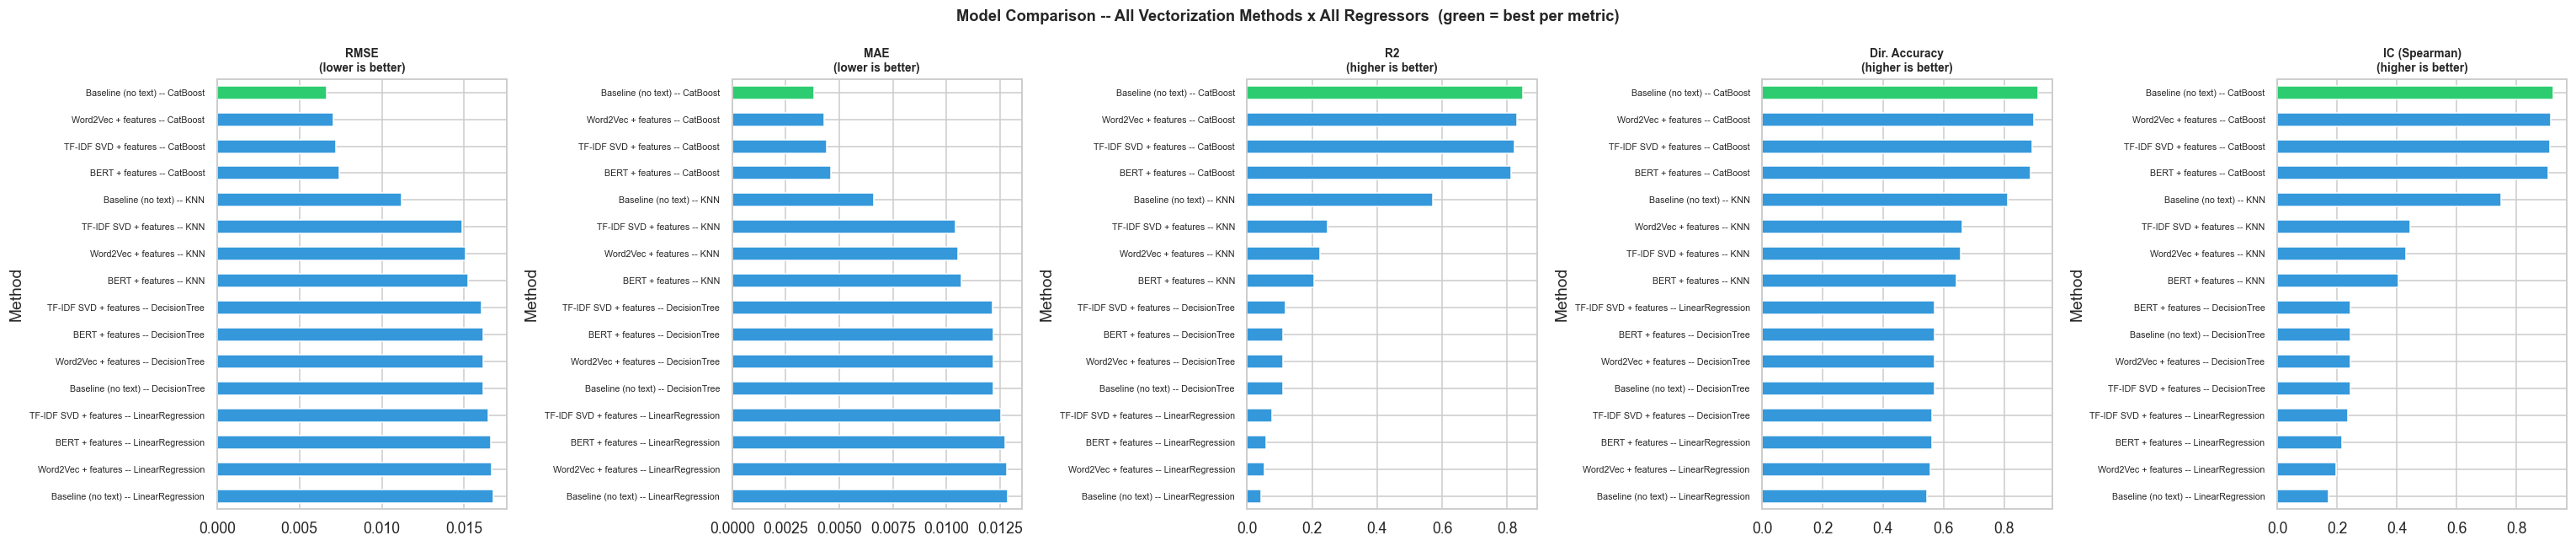


Best method by R2: Baseline (no text) -- CatBoost


In [21]:
METRIC_DISPLAY = [
    ('RMSE',          True),
    ('MAE',           True),
    ('R2',            False),
    ('Dir. Accuracy', False),
    ('IC (Spearman)', False),
]

fig, axes = plt.subplots(1, len(METRIC_DISPLAY), figsize=(28, 6))

for ax, (metric, ascending) in zip(axes, METRIC_DISPLAY):
    vals = results_df[metric].sort_values(ascending=ascending)
    best_val = vals.min() if ascending else vals.max()
    colors = ['#2ecc71' if v == best_val else '#3498db' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    direction = 'lower' if ascending else 'higher'
    ax.set_title(f'{metric}\n({direction} is better)', fontweight='bold', fontsize=9)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle(
    'Model Comparison -- All Vectorization Methods x All Regressors  (green = best per metric)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

best_method = results_df['R2'].idxmax()
print(f'\nBest method by R2: {best_method}')

---
## Feature Importance — Best Model

### Text vs non-text split

In [22]:
# Feature importance is only available for CatBoost models.
# Find the best-performing method prefix that has a CatBoost model.
best_cb_prefix = results_df.loc[
    results_df.index.str.endswith('-- CatBoost'), 'R2'
].idxmax().replace(' -- CatBoost', '')

best_model, best_feat_names, best_c2c = catboost_fi[best_cb_prefix]
print(f'Feature importance for: {best_cb_prefix} -- CatBoost')

importances = best_model.get_feature_importance()
fi_df = (
    pd.DataFrame({'feature': best_feat_names, 'importance': importances})
    .assign(category=lambda x: x['feature'].map(best_c2c).fillna('other'))
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

text_imp = fi_df.loc[fi_df['category'] == 'text_embedding', 'importance'].sum()
meta_imp = fi_df.loc[fi_df['category'] != 'text_embedding', 'importance'].sum()
total    = text_imp + meta_imp

print(f'=== [{best_cb_prefix}] Text vs Non-text Importance ===')
print(f'  Text embeddings  : {text_imp:.2f}  ({100*text_imp/total:.1f}%)')
print(f'  Non-text features: {meta_imp:.2f}  ({100*meta_imp/total:.1f}%)')

Feature importance for: Baseline (no text) -- CatBoost
=== [Baseline (no text)] Text vs Non-text Importance ===
  Text embeddings  : 0.00  (0.0%)
  Non-text features: 100.00  (100.0%)


### Importance by feature category

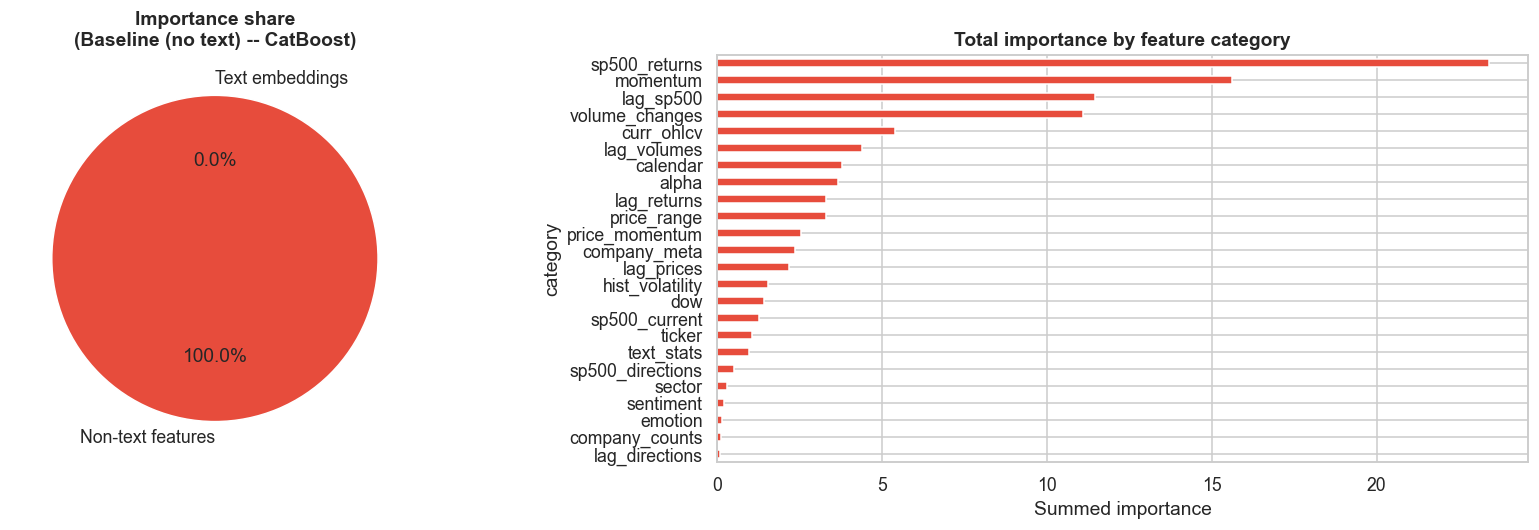


Category importance table (all non-text groups):
category
sp500_returns       23.426
momentum            15.607
lag_sp500           11.451
volume_changes      11.099
curr_ohlcv           5.377
lag_volumes          4.389
calendar             3.793
alpha                3.669
lag_returns          3.301
price_range          3.283
price_momentum       2.536
company_meta         2.366
lag_prices           2.175
hist_volatility      1.544
dow                  1.416
sp500_current        1.260
ticker               1.036
text_stats           0.967
sp500_directions     0.497
sector               0.281
sentiment            0.199
emotion              0.133
company_counts       0.103
lag_directions       0.092


In [23]:
cat_imp = (
    fi_df.groupby('category')['importance']
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── pie: text vs non-text ─────────────────────────────────────────────────────
axes[0].pie(
    [text_imp, meta_imp],
    labels=['Text embeddings', 'Non-text features'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90,
)
axes[0].set_title(f'Importance share\n({best_method})', fontweight='bold')

# ── bar: per category ─────────────────────────────────────────────────────────
colors_bar = ['#3498db' if c == 'text_embedding' else '#e74c3c'
              for c in cat_imp.index]
cat_imp.sort_values().plot(kind='barh', ax=axes[1], color=colors_bar[::-1],
                           edgecolor='white')
axes[1].set_title('Total importance by feature category', fontweight='bold')
axes[1].set_xlabel('Summed importance')

plt.tight_layout()
plt.show()

print('\nCategory importance table (all non-text groups):')
cat_imp_pct = (cat_imp / total * 100).round(3)
print(cat_imp_pct[cat_imp_pct.index != 'text_embedding'].to_string())

### Top-30 individual non-text features

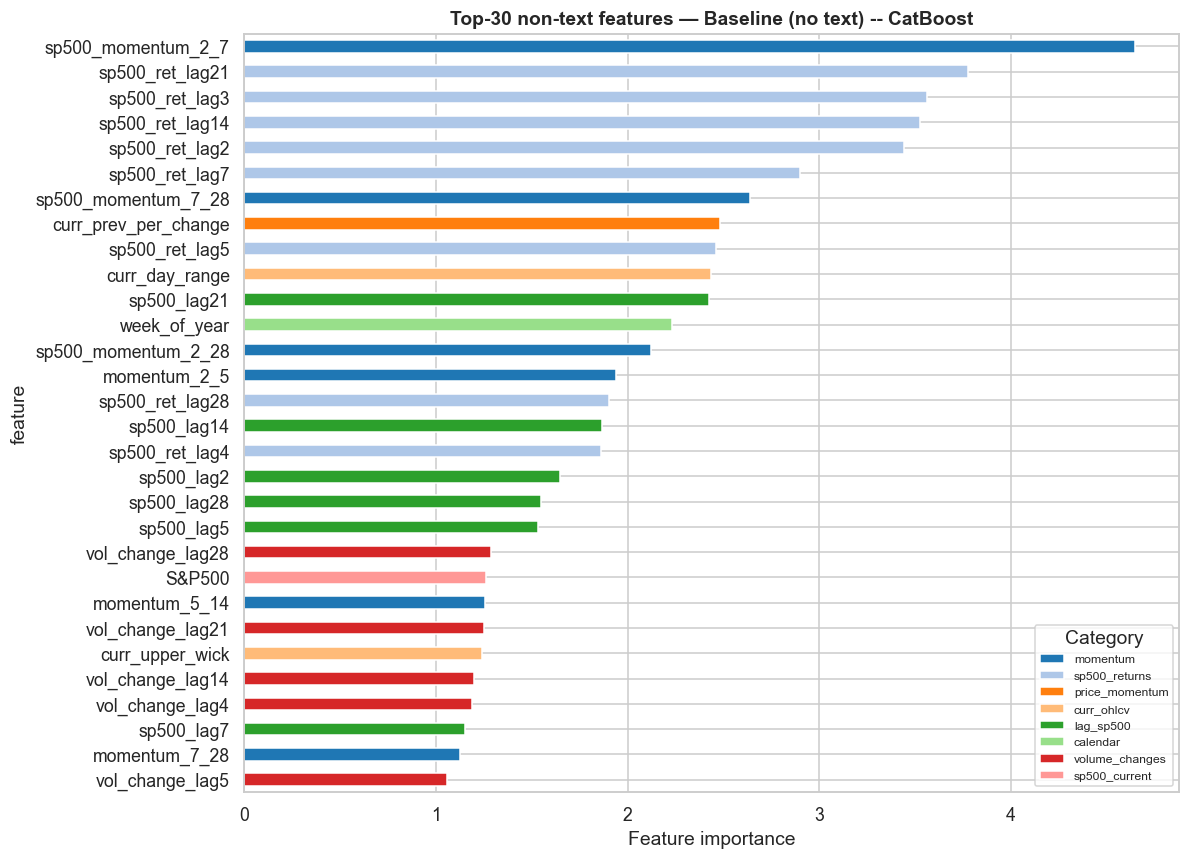

In [24]:
top_non_text = (
    fi_df[fi_df['category'] != 'text_embedding']
    .nlargest(30, 'importance')
    .set_index('feature')
)

# colour bars by category
palette = plt.cm.tab20.colors
unique_cats = list(top_non_text['category'].unique())
cat_color = {c: palette[i % len(palette)] for i, c in enumerate(unique_cats)}
bar_colors = [cat_color[c] for c in top_non_text['category']]

fig, ax = plt.subplots(figsize=(11, 8))
top_non_text['importance'].sort_values().plot(
    kind='barh', ax=ax, color=bar_colors[::-1], edgecolor='white'
)
ax.set_title(f'Top-30 non-text features — {best_method}', fontweight='bold')
ax.set_xlabel('Feature importance')

# legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_color[c], label=c) for c in unique_cats]
ax.legend(handles=legend_elements, title='Category',
          loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### Baseline model — category importance (no text, cleaner signal)

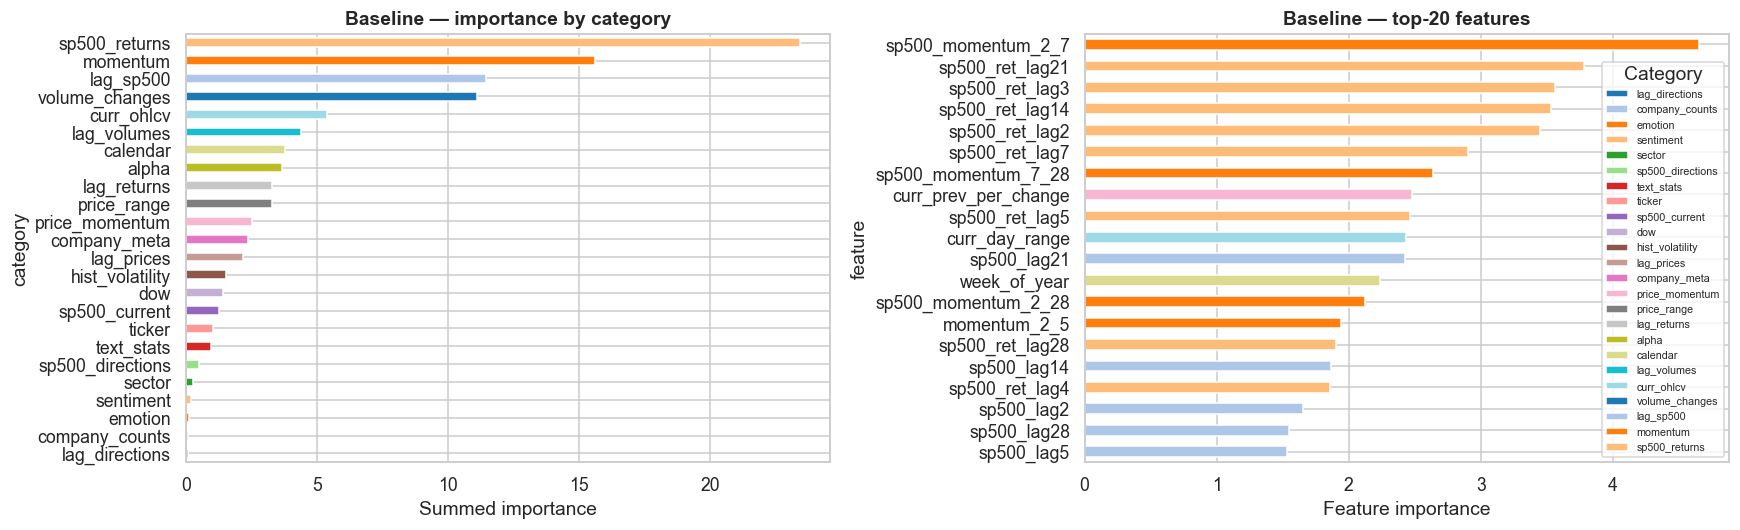


Baseline -- category importance % (sorted):
category
sp500_returns       23.43
momentum            15.61
lag_sp500           11.45
volume_changes      11.10
curr_ohlcv           5.38
lag_volumes          4.39
calendar             3.79
alpha                3.67
lag_returns          3.30
price_range          3.28
price_momentum       2.54
company_meta         2.37
lag_prices           2.18
hist_volatility      1.54
dow                  1.42
sp500_current        1.26
ticker               1.04
text_stats           0.97
sp500_directions     0.50
sector               0.28
sentiment            0.20
emotion              0.13
company_counts       0.10
lag_directions       0.09


In [25]:
base_model, base_feat_names, base_c2c = catboost_fi['Baseline (no text)']
base_imp = base_model.get_feature_importance()

base_fi = (
    pd.DataFrame({'feature': base_feat_names, 'importance': base_imp})
    .assign(category=lambda x: x['feature'].map(base_c2c).fillna('other'))
)

base_cat_imp = (
    base_fi.groupby('category')['importance']
    .sum()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = plt.cm.tab20.colors
all_cats  = list(base_cat_imp.index)
cat_colors_map = {c: palette[i % len(palette)] for i, c in enumerate(all_cats)}
bar_cols = [cat_colors_map[c] for c in base_cat_imp.index]

base_cat_imp.plot(kind='barh', ax=axes[0], color=bar_cols, edgecolor='white')
axes[0].set_title('Baseline — importance by category', fontweight='bold')
axes[0].set_xlabel('Summed importance')

top_base = base_fi.nlargest(20, 'importance').set_index('feature')
top_bar_colors = [cat_colors_map.get(c, 'grey') for c in top_base['category']]
top_base['importance'].sort_values().plot(
    kind='barh', ax=axes[1], color=top_bar_colors[::-1], edgecolor='white'
)
axes[1].set_title('Baseline — top-20 features', fontweight='bold')
axes[1].set_xlabel('Feature importance')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors_map[c], label=c) for c in all_cats]
axes[1].legend(handles=legend_elements, title='Category', fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

print('\nBaseline -- category importance % (sorted):')
total_base = base_imp.sum()
print((base_cat_imp.sort_values(ascending=False) / total_base * 100).round(2).to_string())

---
## Save Best Model

Save the best-performing model (selected by R²) and its metadata to disk.
The agent's `model_tool.py` will load `best_model.cbm` and `best_model_meta.json` once this cell has been run.

In [26]:
best_method = results_df['R2'].idxmax()
model_type, best_model_obj, best_scaler = trained_models[best_method]

META_PATH   = 'best_model_regression_meta.json'
SCALER_PATH = 'best_model_regression_scaler.pkl'

if model_type == 'catboost':
    MODEL_PATH = 'best_model_regression.cbm'
    best_model_obj.save_model(MODEL_PATH)
    print(f'CatBoost model saved -> {MODEL_PATH}')
else:
    MODEL_PATH = 'best_model_regression.pkl'
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(best_model_obj, f)
    print(f'Sklearn model saved -> {MODEL_PATH}')

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(best_scaler, f)
print(f'Scaler saved -> {SCALER_PATH}')

best_metrics = results_df.loc[best_method].to_dict()
meta = {
    'best_method': best_method,
    'model_type':  model_type,
    'text_col':    TEXT_COL,
    'target':      TARGET,
    'split': {
        'train':  int(len(idx_train)),
        'val':    int(len(idx_val)),
        'test':   int(len(idx_test)),
        'method': 'ticker_stratified_random_90_5_5',
    },
    'metrics': {k: round(float(v), 6) for k, v in best_metrics.items()},
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved -> {META_PATH}')

print(f'\n=== Saved model summary ===')
print(f'  Method   : {best_method}')
print(f'  Type     : {model_type}')
for k, v in best_metrics.items():
    print(f'  {k:<20}: {v:.6f}')

CatBoost model saved -> best_model_regression.cbm
Scaler saved -> best_model_regression_scaler.pkl
Metadata saved -> best_model_regression_meta.json

=== Saved model summary ===
  Method   : Baseline (no text) -- CatBoost
  Type     : catboost
  RMSE                : 0.006649
  MAE                 : 0.003840
  Median AE           : 0.002055
  Max Error           : 0.053200
  R2                  : 0.849177
  Expl. Var.          : 0.849184
  Dir. Accuracy       : 0.912799
  IC (Spearman)       : 0.923628


In [27]:
print('aaaaa')

aaaaa
